In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

In [2]:
df = pd.read_csv("customer.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(50, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     50 non-null     int64 
 1   Gender         50 non-null     object
 2   Age            50 non-null     int64 
 3   AnnualIncome   50 non-null     int64 
 4   SpendingScore  50 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.1+ KB


In [6]:
df.isnull().sum()

CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

# Selecting Features

In [7]:
features = [
    "Age",
    "AnnualIncome",
    "SpendingScore"
]

X = df[features]

In [8]:
X

,Age,AnnualIncome,SpendingScore
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


# Scaling Features

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
#finding optimal no of clusters
inertia = []
silhouette_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )


C:\Users\shres\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shres\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shres\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shres\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

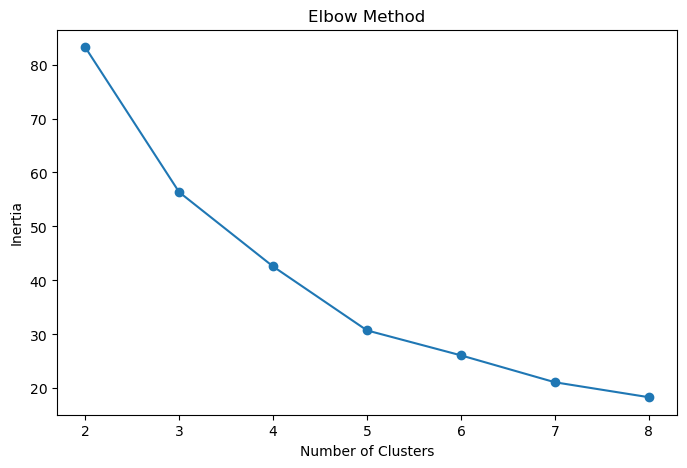

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

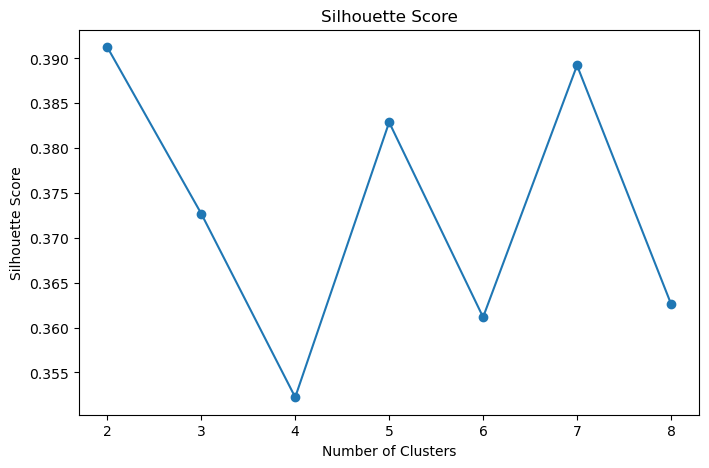

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\shres\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
df[["CustomerID", "Age","AnnualIncome","SpendingScore","Cluster"]].head(20)


,CustomerID,Age,AnnualIncome,SpendingScore,Cluster
0,1,19,15,39,0
1,2,21,15,81,0
2,3,20,16,6,2
3,4,23,16,77,0
4,5,31,17,40,2
5,6,22,17,76,0
6,7,35,18,6,2
7,8,23,18,94,0
8,9,64,19,3,2
9,10,30,19,72,0


In [18]:
cluster_summary = df.groupby("Cluster")[["Age","AnnualIncome","SpendingScore"]].mean()
cluster_summary

,Age,AnnualIncome,SpendingScore
Cluster,,,
0,25.384615,19.384615,77.230769
1,49.250000,34.000000,24.666667
2,43.636364,20.181818,18.272727
3,25.928571,34.857143,69.500000


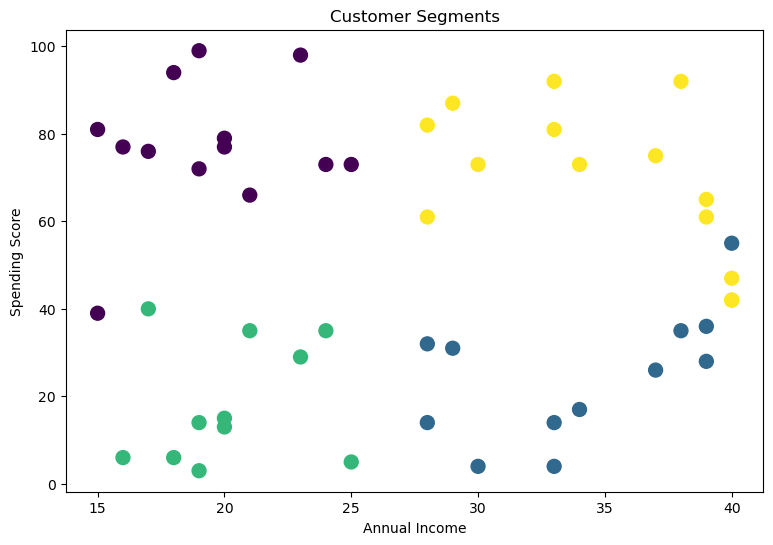

In [19]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

# preparing data

In [21]:
X = df[["Age","AnnualIncome","SpendingScore"]]

y = df["Cluster"]

In [23]:
# splitting
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [24]:
model = RandomForestClassifier(n_estimators=200,random_state=42)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.9

In [27]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00         3\n           1       1.00      0.50      0.67         2\n           2       1.00      1.00      1.00         2\n           3       0.75      1.00      0.86         3\n\n    accuracy                           0.90        10\n   macro avg       0.94      0.88      0.88        10\nweighted avg       0.93      0.90      0.89        10\n'